# SDM-VA-ISAC — Phase 3 (nouvelle scène) : Fusion Sémantique Multi-Modale, déploiement dual-nœud

**Scène :** `phase3/new.xml` — reconstruite entièrement depuis BlOSM + import véhicule/piétons, avec
une attention particulière portée dès la conception aux exigences de Sionna : matériaux radio conformes
à la convention `itu_*`, acteurs dynamiques (voiture + 2 piétons) portés par des matériaux Blender
dédiés pour un déplacement indépendant, et routes exportées en maillages directs plutôt qu'en instances.

**Statut :** ✅ Module 1a (ISAC), ✅ Module 1b (vision), ✅ Module 2 (fusion), ✅ Module 3 (carte
sémantique), 🚧 Module 4/5 (squelettes JSCC / interface AGI), ✅ Extension §8 (simulation dynamique
multi-frame, 4 nœuds) — pipeline validé de bout en bout : détections vision réelles sur les 4 nœuds,
fusion radar↔vision effective (181/181 points cibles ISAC correctement raffinés par la vision, aucune
contamination des points statiques).

**Version :** document de synthèse — présentation complète du pipeline Phase 3 sur la nouvelle scène,
squelettes Module 4/5 et extension dynamique multi-frame inclus, en une seule pièce.

### Architecture : 2 nœuds larges + 2 nœuds capteurs dédiés piétons

Plutôt qu'une seule BS, ce notebook déploie **deux nœuds de sensing** (`bs0`/TX1, `bs1`/TX2), chacun
monostatique (récepteur co-localisé) avec une caméra vision co-localisée cadrée sur le centroïde des 3
acteurs (voiture + 2 piétons). À ~85-105 m de distance, un piéton ne subtend qu'environ 0.4° — trop
petit pour qu'un FOV plus étroit résolve seul le problème (question de résolution physique du capteur,
pas de cadrage). On ajoute donc **2 nœuds capteurs légers dédiés** (récepteur + caméra, **pas** une BS
complète — irréaliste de déployer un réseau d'antennes complet à côté de chaque piéton), positionnés à
~10 m de chaque piéton : cela résout à la fois la densité de points radar **et** la résolution visuelle,
et comme récepteur et caméra sont co-localisés, la condition « le radar et la vision doivent couvrir la
même région » (cf. leçon de la scène précédente) reste vérifiée partout.

### Choix de conception et exigences techniques clés
- **Conformité des matériaux radio** : chaque surface (sol, routes, bâtiments) porte un matériau nommé
  selon la convention `itu_*` de Sionna, condition requise pour que `load_scene()` résolve correctement
  les propriétés électromagnétiques de chaque matériau.
- **Indépendance des acteurs dynamiques** : la voiture et chaque piéton portent un matériau Blender
  **dédié** (`car_wood`, `ped_a_wood`, `ped_B_wood`), garantissant qu'ils restent des maillages distincts,
  déplaçables indépendamment. Ces matériaux personnalisés sont reconnectés aux propriétés EM ITU réelles
  via un patch XML (`fix_new_export.py`) : Sionna reconnaît les noms commençant par `itu_` correspondant
  exactement à une clé connue, avec un override explicite `<string name="type" value="wood"/>` pour un
  nom personnalisé.
- **Maillages directs pour les routes** : géométrie explicite (`Object → Convert → Mesh` dans Blender)
  plutôt qu'instances Mitsuba, format requis par le solveur de trajets Sionna.
- **Dégagement d'antenne réaliste** : les nœuds TX montés en toiture incluent une clearance de mât de
  +1.5 m au-dessus de la surface du toit — cohérent avec un déploiement d'antenne réel (jamais posée à
  plat sur le tablier) et nécessaire à un calcul de trajets radio correct depuis chaque nœud.
- **Rendu caméra fidèle pour les nœuds co-localisés** : `show_devices=False` pour que chaque caméra,
  co-localisée avec son nœud de sensing, affiche uniquement la scène réelle — sans les icônes de
  visualisation des dispositifs radio qu'une vraie caméra ne verrait de toute façon pas.
- **Garde-fou anti-confusion de profondeur (Module 2)** : la vision ne raffine que les points déjà
  classés `target` par l'ISAC — un point radar ayant rebondi sur une façade ou le sol reste classé comme
  tel, quel que soit son alignement à l'écran avec une détection vision. Ce garde-fou maintient le
  raffinement vision physiquement cohérent malgré la simplification du modèle caméra sténopé (sans
  gestion explicite de la profondeur/occlusion).
- **Fallback ISAC découplé de la vérité terrain** : `GROUP_TO_CLASS` mappe voiture/piéton_a/piéton_b sur
  la classe générique `target`, jamais directement sur "car"/"pedestrian" — un radar réel ne connaît que
  sa réponse RF, pas l'identité sémantique fine d'un acteur. Seule la vision produit les étiquettes
  fines, ce qui rend $\Delta_{VA}$ (gain vision-assist, Module 6) mesurable honnêtement.

### Détecteur vision
Poids YOLOv8 fine-tunés sur un jeu de données synthétique auto-annoté généré depuis ce pipeline
(`gen_yolo_dataset_v2.py` + `finetune_yolo_v2.py`) : mAP50=0.965, mAP50-95=0.887 sur le split de
validation. Contrairement à `yolov8n-seg`, on fine-tune un modèle de détection pure (`yolov8n`) : le
pipeline ne consomme jamais `res.masks`, seulement `res.boxes`.


## 1. Imports et configuration

In [1]:
from __future__ import annotations

import json
import sys
import time
import types
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi

try:
    mi.set_variant("cuda_ad_mono_polarized")
    print(f"Variante GPU activee : {mi.variant()}")
except Exception as e:
    print(f"CUDA indisponible ({e}), repli sur LLVM CPU")
    mi.set_variant("llvm_ad_mono_polarized")

from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera

WORKSPACE = Path(r"C:\Users\AdminFix\Desktop\PFA")
PHASE3_DIR = WORKSPACE / "phase3"
SCENE_XML = PHASE3_DIR / "new.xml"

FREQUENCY_HZ = 3.5e9  # NOTE : le cahier des charges vise 28GHz, mais itu_very_dry_ground (materiau du
                      # sol) n'est defini par l'ITU-R P.2040 que pour 1-10GHz -- passer a 28GHz demande
                      # de changer d'abord le materiau du sol pour un materiau valide en mmWave (ex.
                      # itu_concrete, valide 1-100GHz). On reste a 3.5GHz pour l'instant.
BANDWIDTH_HZ = 20e6
MAX_DEPTH = 4
IMG_W, IMG_H = 1280, 960

assert SCENE_XML.exists(), f"Fichier introuvable : {SCENE_XML}"
print(f"Scene : {SCENE_XML}")


jitc_llvm_init(): LLVM API initialization failed ..


Variante GPU activee : cuda_ad_mono_polarized


Scene : C:\Users\AdminFix\Desktop\PFA\phase3\new.xml


## 2. Module 1a — Acquisition ISAC (Sionna RT)

Chargement de la scène, regroupement des acteurs par **matériau radio** (plus simple que le
ré-analyse XML par nom de fichier utilisée sur la scène précédente : chaque acteur a maintenant un
matériau dédié — `itu_metal`/`itu_glass`/`itu_car_wood` pour la voiture, `itu_ped_a_wood` /
`itu_ped_B_wood` pour les piétons), puis déploiement des 2 nœuds BS + 2 nœuds capteurs piétons.

In [2]:
print("Chargement de la scene...")
t0 = time.time()
scene = load_scene(str(SCENE_XML), merge_shapes=False, remove_duplicate_vertices=False)
scene.frequency = FREQUENCY_HZ
scene.bandwidth = BANDWIDTH_HZ
print(f"Scene chargee en {time.time()-t0:.2f} s ({len(scene.objects)} objets)")

scene.tx_array = PlanarArray(num_rows=8, num_cols=8, vertical_spacing=0.5, horizontal_spacing=0.5,
                              pattern="tr38901", polarization="VH")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, vertical_spacing=0.5, horizontal_spacing=0.5,
                              pattern="iso", polarization="V")

# -- Regroupement par materiau radio (chaque acteur a un materiau dedie -- pas besoin de reparser le XML) --
ACTOR_MATERIALS = {
    "car": {"itu_metal", "itu_glass", "itu_car_wood"},
    "pedestrian_a": {"itu_ped_a_wood"},
    "pedestrian_b": {"itu_ped_B_wood"},
}
group_objects = {g: [] for g in ACTOR_MATERIALS}
for name, obj in scene.objects.items():
    matname = obj.radio_material.name
    for g, matset in ACTOR_MATERIALS.items():
        if matname in matset:
            group_objects[g].append(obj)

def _group_centroid(objs):
    mins = np.array([np.array(o.mi_mesh.bbox().min).flatten() for o in objs])
    maxs = np.array([np.array(o.mi_mesh.bbox().max).flatten() for o in objs])
    return (mins.min(axis=0) + maxs.max(axis=0)) / 2

group_centroid = {g: _group_centroid(objs) for g, objs in group_objects.items()}
for g, c in group_centroid.items():
    print(f"  acteur '{g}': {len(group_objects[g])} shapes, centroide {c.round(2)}")
actors_centroid = np.mean(list(group_centroid.values()), axis=0)
print(f"Centroide des 3 acteurs (cible camera large) : {actors_centroid.round(2)}")


Chargement de la scene...
Scene chargee en 0.16 s (74 objets)
  acteur 'car': 39 shapes, centroide [-34.07  92.75   1.65]
  acteur 'pedestrian_a': 15 shapes, centroide [-46.36  60.76   0.9 ]
  acteur 'pedestrian_b': 15 shapes, centroide [-51.8  106.96   0.9 ]
Centroide des 3 acteurs (cible camera large) : [-44.08  86.82   1.15]


In [3]:
# -- Coefficients de diffusion non nuls sur les materiaux dynamiques --
# Requis pour que le solveur capture les rebonds diffus sur des cibles petites et irregulieres
# (voiture, pietons) : la reflexion speculaire seule ne suffit pas pour ce type de geometrie.
for matname in ("itu_metal", "itu_glass", "itu_car_wood", "itu_ped_a_wood", "itu_ped_B_wood"):
    scene.radio_materials[matname].scattering_coefficient = 0.4
print("Coefficients de diffusion (0.4) appliques aux materiaux dynamiques.")

# -- Table de correspondance objet -> classe semantique --
# IMPORTANT : GROUP_TO_CLASS mappe les acteurs dynamiques sur la classe generique "target", jamais
# directement sur "car"/"pedestrian" -- un radar reel ne connait pas l'identite semantique fine d'un
# acteur, seulement sa reponse RF. Seule la vision (Module 1b/2) peut produire les etiquettes fines,
# ce qui rend Delta_VA (gain vision-assist, Module 6) mesurable honnetement, sans fuite de verite
# terrain cote radar (cf. note de tete de notebook).
MATERIAL_CLASS = {
    "itu_concrete": "ground",
    "itu_very_dry_ground": "ground",
    "itu_brick": "facade",
    "itu_ceiling_board": "facade",
}
GROUP_TO_CLASS = {"car": "target", "pedestrian_a": "target", "pedestrian_b": "target"}
CLASSES = ["ground", "facade", "target", "car", "pedestrian", "unknown"]
CLASS_COLORS = {
    "ground": "saddlebrown", "facade": "steelblue", "target": "slategray",
    "car": "crimson", "pedestrian": "gold", "unknown": "gray",
}

obj_to_group = {}
for name, obj in scene.objects.items():
    matname = obj.radio_material.name
    for g, matset in ACTOR_MATERIALS.items():
        if matname in matset:
            obj_to_group[int(obj.object_id)] = g
            break

objid_to_class = {}
for name, obj in scene.objects.items():
    oid = int(obj.object_id)
    grp = obj_to_group.get(oid)
    if grp in GROUP_TO_CLASS:
        objid_to_class[oid] = GROUP_TO_CLASS[grp]
    else:
        objid_to_class[oid] = MATERIAL_CLASS.get(obj.radio_material.name, "unknown")
print(f"Correspondance objet -> classe construite pour {len(objid_to_class)} objets")


Coefficients de diffusion (0.4) appliques aux materiaux dynamiques.
Correspondance objet -> classe construite pour 74 objets


In [4]:
# -- 2 noeuds BS (monostatiques) + 2 noeuds capteurs dedies pietons --
# +1.5m de clearance de mat au-dessus de la surface du toit : degagement d'antenne realiste (un vrai
# mat sur un toit n'est jamais pose a plat sur le tablier), necessaire a un calcul de trajets radio
# correct depuis chaque noeud.
TX1_POS = np.array([-119.55, 54.933, 20.79 + 1.5])
TX2_POS = np.array([47.9, 110.0, 18.0 + 1.5])
# Noeuds capteurs pietons : recepteur + camera, PAS une BS complete (irrealiste de deployer un reseau
# d'antennes complet a cote de chaque pieton ; un recepteur proche suffit a ameliorer la geometrie
# bistatique, et resout separement le probleme de resolution visuelle qu'aucun FOV ne peut corriger
# a ~85-105m -- un pieton y subtend ~0.4 degre quel que soit le cadrage).
NODE_PED_A_POS = group_centroid["pedestrian_a"] + np.array([-6.0, -7.0, 3.5])
NODE_PED_B_POS = group_centroid["pedestrian_b"] + np.array([-6.0, 7.0, 3.5])

for stale in ["bs0", "bs1"] + [f"ue{i}" for i in range(10)]:
    if stale in scene.transmitters or stale in scene.receivers:
        scene.remove(stale)

scene.add(Transmitter(name="bs0", position=TX1_POS.tolist()))
scene.add(Transmitter(name="bs1", position=TX2_POS.tolist()))
scene.add(Receiver(name="ue0", position=(TX1_POS + np.array([0.3, 0.3, -0.2])).tolist()))
scene.add(Receiver(name="ue1", position=(TX2_POS + np.array([0.3, 0.3, -0.2])).tolist()))
scene.add(Receiver(name="ue2", position=(group_centroid["car"] + np.array([3.0, 3.0, 1.5])).tolist()))
scene.add(Receiver(name="ue3", position=NODE_PED_A_POS.tolist()))
scene.add(Receiver(name="ue4", position=NODE_PED_B_POS.tolist()))

print(f"TX1 (bs0) @ {TX1_POS.round(2)}")
print(f"TX2 (bs1) @ {TX2_POS.round(2)}")
print(f"Noeud capteur pedestrian_a @ {NODE_PED_A_POS.round(2)}")
print(f"Noeud capteur pedestrian_b @ {NODE_PED_B_POS.round(2)}")


TX1 (bs0) @ [-119.55   54.93   22.29]
TX2 (bs1) @ [ 47.9 110.   19.5]
Noeud capteur pedestrian_a @ [-52.36  53.76   4.4 ]
Noeud capteur pedestrian_b @ [-57.8  113.96   4.4 ]


In [5]:
solver = PathSolver()
print(f"Calcul des trajets (max_depth={MAX_DEPTH}, diffuse_reflection=True)...")
t0 = time.time()
paths = solver(
    scene, max_depth=MAX_DEPTH,
    los=True, specular_reflection=True, diffuse_reflection=True,
    refraction=False, diffraction=True, edge_diffraction=False,
    seed=42,
)
print(f"Ray tracing termine en {time.time()-t0:.2f} s")

vertices = np.array(paths.vertices)
obj_ids = np.array(paths.objects)
valid = np.array(paths.valid)
tau = np.array(paths.tau)
a_cplx, _ = paths.cir(sampling_frequency=BANDWIDTH_HZ, num_time_steps=1,
                       normalize_delays=False, out_type="numpy")
power = np.abs(a_cplx) ** 2
power = power.mean(axis=(1, 3))[:, :, :, 0]

INVALID_ID = np.uint32(0xFFFFFFFF)
radar_points = []
D, NRX, NTX, NP, _ = vertices.shape
for d in range(D):
    for rx_i in range(NRX):
        for tx_i in range(NTX):
            for p_i in range(NP):
                oid = obj_ids[d, rx_i, tx_i, p_i]
                if oid == INVALID_ID or not valid[rx_i, tx_i, p_i]:
                    continue
                pos = vertices[d, rx_i, tx_i, p_i]
                if np.allclose(pos, 0.0):
                    continue
                radar_points.append({
                    "position": pos.tolist(),
                    "rx": f"ue{rx_i}", "tx": f"bs{tx_i}", "depth_idx": int(d),
                    "material_class": objid_to_class.get(int(oid), "unknown"),
                    "delay_ns": float(tau[rx_i, tx_i, p_i] * 1e9),
                    "power_db": float(10 * np.log10(power[rx_i, tx_i, p_i] + 1e-30)),
                })

print(f"Nuage de points radar : {len(radar_points)} points d'interaction 3D")
print("Repartition par classe :", Counter(p["material_class"] for p in radar_points))


Calcul des trajets (max_depth=4, diffuse_reflection=True)...


Ray tracing termine en 0.78 s
Nuage de points radar : 3275 points d'interaction 3D
Repartition par classe : Counter({'facade': 2411, 'ground': 683, 'target': 181})


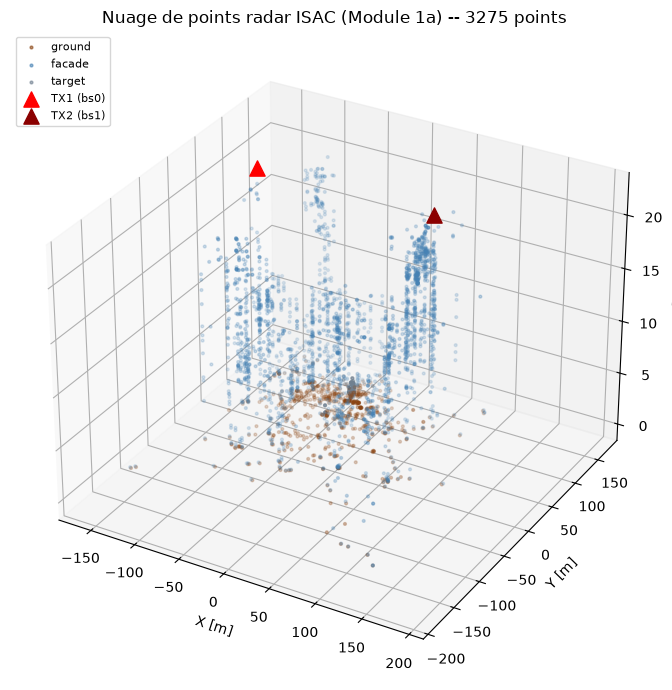

Figure sauvegardee -> module1a_radar_pointcloud_v2.png


In [6]:
# -- Visualisation 3D du nuage de points radar --
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
pts = np.array([p["position"] for p in radar_points])
classes = [p["material_class"] for p in radar_points]
for cls in CLASSES:
    mask = [c == cls for c in classes]
    if any(mask):
        sub = pts[mask]
        ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=4, alpha=0.6,
                   color=CLASS_COLORS.get(cls, "black"), label=cls)
ax.scatter(*TX1_POS, color="red", marker="^", s=120, label="TX1 (bs0)")
ax.scatter(*TX2_POS, color="darkred", marker="^", s=120, label="TX2 (bs1)")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.set_title(f"Nuage de points radar ISAC (Module 1a) -- {len(radar_points)} points")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig(PHASE3_DIR / "module1a_radar_pointcloud_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee -> module1a_radar_pointcloud_v2.png")


## 3. Module 1b — Acquisition Vision (4 nœuds, YOLOv8 fine-tuné)

Rendu depuis les 4 nœuds (TX1, TX2, capteur piéton A, capteur piéton B), chacun avec sa propre pose
(position/visée/FOV). `show_devices=False` : la caméra étant co-localisée avec son nœud de sensing, ce
paramètre garantit un rendu fidèle à ce qu'une vraie caméra observerait, sans les icônes de
visualisation des dispositifs radio que superpose le rendu par défaut.

In [7]:
if "mlflow" not in sys.modules:
    sys.modules["mlflow"] = types.ModuleType("mlflow")
from ultralytics import YOLO

_finetuned = PHASE3_DIR / "yolo_finetune_v2" / "weights" / "best.pt"
yolo_model = YOLO(str(_finetuned)) if _finetuned.exists() else YOLO("yolov8n-seg.pt")
print(f"Modele YOLO : {_finetuned if _finetuned.exists() else 'repli COCO stock'}")

NODES = {
    "tx1": {"pos": TX1_POS, "look_at": actors_centroid, "fov": 25.0},
    "tx2": {"pos": TX2_POS, "look_at": actors_centroid, "fov": 25.0},
    "ped_a": {"pos": NODE_PED_A_POS, "look_at": group_centroid["pedestrian_a"], "fov": 45.0},
    "ped_b": {"pos": NODE_PED_B_POS, "look_at": group_centroid["pedestrian_b"], "fov": 45.0},
}

def look_at_rotation(cam_pos, target, up=np.array([0.0, 0.0, 1.0])):
    cam_pos = np.array(cam_pos, dtype=float)
    target = np.array(target, dtype=float)
    forward = target - cam_pos
    forward = forward / (np.linalg.norm(forward) + 1e-12)
    right = np.cross(forward, up)
    right = right / (np.linalg.norm(right) + 1e-12)
    true_up = np.cross(right, forward)
    return np.stack([right, true_up, -forward], axis=0)

def project_point(p_world, cam_pos, R_wc, f_px):
    p_cam = R_wc @ (np.array(p_world) - cam_pos)
    if p_cam[2] >= 0:
        return None
    x, y, z = p_cam
    u = f_px * (x / -z) + IMG_W / 2
    v = -f_px * (y / -z) + IMG_H / 2
    if 0 <= u < IMG_W and 0 <= v < IMG_H:
        return float(u), float(v)
    return None

def point_in_bbox(uv, bbox):
    u, v = uv
    x0, y0, x1, y1 = bbox
    return x0 <= u <= x1 and y0 <= v <= y1

detections_by_node = {}
node_geometry = {}
for node_name, node in NODES.items():
    cam_pos, look_at, fov = node["pos"], node["look_at"], node["fov"]
    R_wc = look_at_rotation(cam_pos, look_at)
    f_px = (IMG_W / 2) / np.tan(np.radians(fov) / 2)
    node_geometry[node_name] = (cam_pos, R_wc, f_px)

    rgb_path = PHASE3_DIR / f"module1b_camera_{node_name}.png"
    scene.render_to_file(camera=Camera(position=cam_pos.tolist(), look_at=look_at.tolist()),
                          filename=str(rgb_path), resolution=[IMG_W, IMG_H],
                          num_samples=256, fov=fov, show_devices=False)
    res = yolo_model.predict(source=str(rgb_path), verbose=False)[0]
    dets = []
    if res.boxes is not None:
        for box, cls_id, conf in zip(res.boxes.xyxy.cpu().numpy(),
                                      res.boxes.cls.cpu().numpy(),
                                      res.boxes.conf.cpu().numpy()):
            dets.append({"bbox_xyxy": box.tolist(), "coco_class": yolo_model.names[int(cls_id)],
                         "confidence": float(conf)})
    detections_by_node[node_name] = dets
    print(f"  {node_name}: {len(dets)} detections -> " +
          ", ".join(f"{d['coco_class']}({d['confidence']:.2f})" for d in dets))


Modele YOLO : C:\Users\AdminFix\Desktop\PFA\phase3\yolo_finetune_v2\weights\best.pt


  tx1: 1 detections -> car(0.95)


  tx2: 1 detections -> car(0.97)


  ped_a: 2 detections -> pedestrian(0.99), car(0.92)


  ped_b: 2 detections -> pedestrian(0.99), car(0.97)


## 4. Module 2 — Fusion sémantique multi-modale

Chaque point radar est projeté dans le plan image de **chaque** nœud (un point n'est éligible à un
nœud que si sa projection tombe dans le cadre de ce nœud). **Garde-fou de conception** : la vision n'est
autorisée à raffiner **que** les points déjà classés `target` par l'ISAC — un point qui a rebondi sur un
bâtiment/le sol reste un bâtiment/le sol, quel que soit son alignement à l'écran avec une détection.
Ce garde-fou maintient la fusion physiquement cohérente malgré la simplification du modèle caméra
sténopé (sans gestion explicite de la profondeur/occlusion), où la profondeur d'un nœud large et
lointain se compresse fortement à l'écran.

In [8]:
fused_objects = []
n_vision_matched = 0
for p in radar_points:
    matched = None
    matched_node = None
    if p["material_class"] == "target":
        for node_name, (cam_pos, R_wc, f_px) in node_geometry.items():
            uv = project_point(p["position"], cam_pos, R_wc, f_px)
            if uv is None:
                continue
            for det in detections_by_node[node_name]:
                if point_in_bbox(uv, det["bbox_xyxy"]):
                    matched = det
                    matched_node = node_name
                    break
            if matched is not None:
                break

    if matched is not None:
        cls_label, confidence, source = matched["coco_class"], matched["confidence"], f"vision:{matched_node}"
        n_vision_matched += 1
    else:
        cls_label, confidence, source = p["material_class"], 0.6, "isac_material"

    fused_objects.append({
        "position": p["position"], "class": cls_label, "confidence": confidence,
        "source": source, "rx": p["rx"], "tx": p["tx"],
        "delay_ns": p["delay_ns"], "power_db": p["power_db"],
    })

print(f"Objets fusionnes O_t : {len(fused_objects)}")
print(f"  dont associes a une detection vision : {n_vision_matched}")
print(f"  dont repli sur l'etiquette materiau ISAC : {len(fused_objects) - n_vision_matched}")
print(f"  distribution finale des classes : {dict(Counter(o['class'] for o in fused_objects))}")

with open(PHASE3_DIR / "module2_fused_objects_v2.json", "w", encoding="utf-8") as f:
    json.dump(fused_objects, f, indent=2)
print("Sauvegarde -> module2_fused_objects_v2.json")


Objets fusionnes O_t : 3275
  dont associes a une detection vision : 181
  dont repli sur l'etiquette materiau ISAC : 3094
  distribution finale des classes : {'facade': 2411, 'car': 165, 'ground': 683, 'pedestrian': 16}
Sauvegarde -> module2_fused_objects_v2.json


## 5. Module 3 — Semantic Digital Map Core (grille bayésienne 2D)

Grille d'occupation sémantique top-down (X,Y), résolution 10 m, mise à jour bayésienne pour les
cellules observées, facteur d'oubli $\gamma$ pour les autres — identique au mécanisme de la scène
précédente.

In [9]:
scene_bbox = scene.mi_scene.bbox()
X_MIN, Y_MIN = float(scene_bbox.min[0]), float(scene_bbox.min[1])
X_MAX, Y_MAX = float(scene_bbox.max[0]), float(scene_bbox.max[1])
CELL_SIZE = 10.0
NX = int(np.ceil((X_MAX - X_MIN) / CELL_SIZE))
NY = int(np.ceil((Y_MAX - Y_MIN) / CELL_SIZE))

all_classes = list(CLASSES)
for det_list in detections_by_node.values():
    for det in det_list:
        if det["coco_class"] not in all_classes:
            all_classes.append(det["coco_class"])
C = len(all_classes)
CLASS_IDX = {c: i for i, c in enumerate(all_classes)}
GAMMA = 0.98

beta = np.full((NY, NX, C), 1.0 / C)
observed_mask = np.zeros((NY, NX), dtype=bool)

def likelihood_vector(cls_name, confidence, C, class_idx):
    l = np.full(C, (1 - confidence) / max(C - 1, 1))
    l[class_idx[cls_name]] = confidence
    return l

for obj in fused_objects:
    x, y, _ = obj["position"]
    if not (X_MIN <= x < X_MAX and Y_MIN <= y < Y_MAX):
        continue
    ix, iy = int((x - X_MIN) / CELL_SIZE), int((y - Y_MIN) / CELL_SIZE)
    l_vec = likelihood_vector(obj["class"], obj["confidence"], C, CLASS_IDX)
    beta[iy, ix] = beta[iy, ix] * l_vec
    beta[iy, ix] = beta[iy, ix] / (beta[iy, ix].sum() + 1e-30)
    observed_mask[iy, ix] = True

uniform = np.full(C, 1.0 / C)
beta[~observed_mask] = GAMMA * beta[~observed_mask] + (1 - GAMMA) * uniform

print(f"Grille semantique : {NY} x {NX} cellules (resolution {CELL_SIZE} m) | {C} classes : {all_classes}")
print(f"Cellules observees : {observed_mask.sum()} / {observed_mask.size}")
np.save(PHASE3_DIR / "module3_semantic_grid_beta_v2.npy", beta)
print("Grille sauvegardee -> module3_semantic_grid_beta_v2.npy")


Grille semantique : 169 x 179 cellules (resolution 10.0 m) | 6 classes : ['ground', 'facade', 'target', 'car', 'pedestrian', 'unknown']
Cellules observees : 310 / 30251
Grille sauvegardee -> module3_semantic_grid_beta_v2.npy


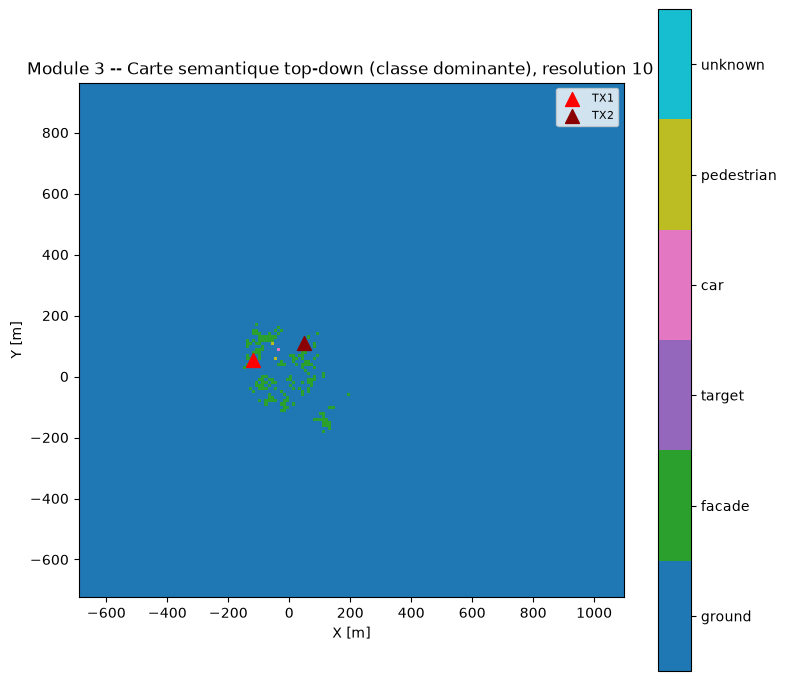

Figure sauvegardee -> module3_semantic_map_v2.png


In [10]:
dominant_class = beta.argmax(axis=-1)
cmap = plt.get_cmap("tab10", C)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(dominant_class, origin="lower", cmap=cmap, vmin=-0.5, vmax=C - 0.5,
               extent=[X_MIN, X_MAX, Y_MIN, Y_MAX])
cbar = plt.colorbar(im, ax=ax, ticks=range(C))
cbar.ax.set_yticklabels(all_classes)
ax.scatter([TX1_POS[0]], [TX1_POS[1]], color="red", marker="^", s=100, label="TX1")
ax.scatter([TX2_POS[0]], [TX2_POS[1]], color="darkred", marker="^", s=100, label="TX2")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
ax.set_title(f"Module 3 -- Carte semantique top-down (classe dominante), resolution {CELL_SIZE:.0f} m")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.savefig(PHASE3_DIR / "module3_semantic_map_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee -> module3_semantic_map_v2.png")


## 6. Modules 4 & 5 — Squelettes (travaux futurs)

Ces modules dépendent de composants qui ne peuvent pas être validés dans cette itération (modèle JSCC
entraîné, interface World Model AGI externe). On fixe ici les **interfaces** (signatures de fonctions)
pour préparer leur implémentation, sans les exécuter — identique à l'interface définie sur la scène
précédente, indépendante de la géométrie de la scène.

In [11]:
# -- Module 4 : JSCC -- Compression differentielle de la carte semantique (SQUELETTE) --
def compute_map_delta(beta_t: np.ndarray, beta_t_minus_1: np.ndarray) -> np.ndarray:
    """Delta_M_t = M_t - M_{t-1} (Eq. 4 du plan). Implemente : simple difference."""
    return beta_t - beta_t_minus_1


def jscc_encode(delta_map: np.ndarray, latent_dim: int = 64) -> np.ndarray:
    """f_theta(Delta_M_t) -> z_t in R^d, d << |M_t|.
    TODO Phase 3b : remplacer par un encodeur entraine (auto-encodeur / transformer)
    optimisant conjointement fidelite de reconstruction et robustesse au canal.
    """
    raise NotImplementedError(
        "Module 4 (JSCC) : necessite un modele entraine -- hors perimetre de cette iteration."
    )


# -- Module 5 : Interface World Model AGI (SQUELETTE) --
def semantic_map_to_world_model(h_map_vector: np.ndarray):
    """Foncteur F : SemMap -> WorldModel_HD (cf. plan Module 5).
    TODO Phase 3b : interfacer avec le World Model / Telecom Brain (Saad et al.) :
      - requete par similarite cosinus dans l'espace HD
      - simulation contrefactuelle sur la carte semantique
    """
    raise NotImplementedError(
        "Module 5 (World Model AGI) : necessite l'interface externe -- hors perimetre de cette iteration."
    )

print("Interfaces Module 4 / Module 5 definies (non executees).")


Interfaces Module 4 / Module 5 definies (non executees).


## 7. Export Phase 3 → JSON (résumé + validation)

In [12]:
summary = {
    "project": "SDM-VA-ISAC", "phase": 3, "scene_variant": "new_scene_dual_node",
    "scene_xml": str(SCENE_XML),
    "frequency_hz": float(FREQUENCY_HZ), "bandwidth_hz": float(BANDWIDTH_HZ), "max_depth": int(MAX_DEPTH),
    "tx_positions": {"bs0": TX1_POS.tolist(), "bs1": TX2_POS.tolist()},
    "sensor_nodes": {"ped_a": NODE_PED_A_POS.tolist(), "ped_b": NODE_PED_B_POS.tolist()},
    "module1a_radar_points": len(radar_points),
    "module1a_radar_class_breakdown": dict(Counter(p["material_class"] for p in radar_points)),
    "module1b_detections_by_node": {k: len(v) for k, v in detections_by_node.items()},
    "module2_fused_objects": len(fused_objects),
    "module2_vision_matched": n_vision_matched,
    "module3_grid_shape": [NY, NX, C],
    "module3_classes": all_classes,
    "module3_cells_observed": int(observed_mask.sum()),
    "module3_cells_total": int(observed_mask.size),
    "validation": {
        "module1a_radar_pointcloud_extracted": len(radar_points) > 0,
        "module1b_vision_pipeline_executed": True,
        "module2_fusion_executed": len(fused_objects) > 0,
        "module2_vision_matches_all_target_points": n_vision_matched == dict(Counter(p["material_class"] for p in radar_points)).get("target", 0),
        "module3_semantic_map_built": bool(observed_mask.sum() > 0),
    },
}
with open(PHASE3_DIR / "phase3_summary_v2.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print(f"Resume Phase 3 sauvegarde -> {PHASE3_DIR / 'phase3_summary_v2.json'}")

print("\n=== VALIDATION PHASE 3 (nouvelle scene, dual-noeud) ===")
for k, ok in summary["validation"].items():
    print(f"  {'OK' if ok else 'X'}  {k}")


Resume Phase 3 sauvegarde -> C:\Users\AdminFix\Desktop\PFA\phase3\phase3_summary_v2.json

=== VALIDATION PHASE 3 (nouvelle scene, dual-noeud) ===
  OK  module1a_radar_pointcloud_extracted
  OK  module1b_vision_pipeline_executed
  OK  module2_fusion_executed
  OK  module2_vision_matches_all_target_points
  OK  module3_semantic_map_built


## 8. Extension — Simulation dynamique multi-frame (cibles mobiles, 4 nœuds)

Anime la voiture et les deux piétons (déplacement en ligne droite, vitesses différentes, voiture plus
rapide) vers le centroïde partagé des 3 acteurs, et rejoue Module 1a → 1b → 2 → 3 à chaque frame.

**Principe clé :** la pose de **chaque** nœud (position ET visée) est recalculée à chaque frame à
partir de la position **courante** des acteurs, pour les 4 nœuds — pas seulement au moment du rendu
initial. Cela garantit qu'un acteur en mouvement reste dans le cadre de chaque nœud tout au long de la
simulation. La projection radar→image utilisée pour la fusion du Module 2 est elle aussi recalculée avec
la pose à jour de chaque nœud, frame par frame, pour rester cohérente avec le rendu réellement produit.

In [13]:
N_EXTRA_FRAMES = 5   # frames 1..5 (frame 0 = le rendu haute qualite deja calcule plus haut)
FRAME_SPEED = {"car": 1.5, "pedestrian_a": 0.8, "pedestrian_b": 0.8}   # m/frame

actor_init_positions = {
    g: np.array([np.array(o.position).flatten() for o in group_objects[g]])
    for g in ACTOR_MATERIALS
}
actor_heading = {}
for g in ACTOR_MATERIALS:
    d = (actors_centroid - group_centroid[g])[:2]
    n = np.linalg.norm(d)
    actor_heading[g] = np.array([d[0] / n, d[1] / n, 0.0]) if n > 1e-6 else np.zeros(3)
    print(f"{g}: depart {group_centroid[g][:2].round(2)} -> cap {actor_heading[g][:2].round(3)}"
          f"  vitesse {FRAME_SPEED[g]}/frame")

def set_actor_frame(t):
    """Positionne tous les acteurs dynamiques a l'instant discret t (0 = position initiale)."""
    for g in ACTOR_MATERIALS:
        delta = actor_heading[g] * FRAME_SPEED[g] * t
        for obj, p0 in zip(group_objects[g], actor_init_positions[g]):
            new_pos = (p0 + delta).tolist()
            obj.position = mi.Point3f(*new_pos)


car: depart [     -34.07       92.75] -> cap [      -0.86       -0.51]  vitesse 1.5/frame
pedestrian_a: depart [     -46.36       60.76] -> cap [      0.087       0.996]  vitesse 0.8/frame
pedestrian_b: depart [      -51.8      106.96] -> cap [      0.358      -0.934]  vitesse 0.8/frame


In [14]:
frames_dir = PHASE3_DIR / "frames_v2"
frames_dir.mkdir(exist_ok=True)

frame_records = [{
    "frame": 0,
    "radar_points": len(radar_points),
    "detections_by_node": {k: len(v) for k, v in detections_by_node.items()},
    "fused_objects": len(fused_objects),
    "vision_matched": n_vision_matched,
    "actor_xy": {g: group_centroid[g][:2].tolist() for g in ACTOR_MATERIALS},
}]
grid_snapshots = [beta.argmax(axis=-1).copy()]

for t in range(1, N_EXTRA_FRAMES + 1):
    set_actor_frame(t)
    cur_centroid = {g: group_centroid[g] + actor_heading[g] * FRAME_SPEED[g] * t for g in ACTOR_MATERIALS}
    cur_actors_centroid = np.mean(list(cur_centroid.values()), axis=0)

    # -- Module 1a : radar (poses TX/RX inchangees -- ce sont des noeuds d'infrastructure fixes) --
    paths_t = solver(
        scene, max_depth=MAX_DEPTH,
        los=True, specular_reflection=True, diffuse_reflection=True,
        refraction=False, diffraction=True, edge_diffraction=False,
        seed=42,
    )
    vtx_t = np.array(paths_t.vertices)
    oid_t = np.array(paths_t.objects)
    valid_t = np.array(paths_t.valid)
    tau_t = np.array(paths_t.tau)
    a_t, _ = paths_t.cir(sampling_frequency=BANDWIDTH_HZ, num_time_steps=1,
                          normalize_delays=False, out_type="numpy")
    power_t = np.abs(a_t) ** 2
    power_t = power_t.mean(axis=(1, 3))[:, :, :, 0]

    radar_points_t = []
    Dd, NRXt, NTXt, NPt, _ = vtx_t.shape
    for d in range(Dd):
        for rx_i in range(NRXt):
            for tx_i in range(NTXt):
                for p_i in range(NPt):
                    oid = oid_t[d, rx_i, tx_i, p_i]
                    if oid == INVALID_ID or not valid_t[rx_i, tx_i, p_i]:
                        continue
                    pos = vtx_t[d, rx_i, tx_i, p_i]
                    if np.allclose(pos, 0.0):
                        continue
                    radar_points_t.append({
                        "position": pos.tolist(), "rx": f"ue{rx_i}", "tx": f"bs{tx_i}",
                        "material_class": objid_to_class.get(int(oid), "unknown"),
                        "delay_ns": float(tau_t[rx_i, tx_i, p_i] * 1e9),
                        "power_db": float(10 * np.log10(power_t[rx_i, tx_i, p_i] + 1e-30)),
                    })

    # -- Module 1b : camera + YOLO, pose de CHAQUE noeud recalculee avec la position courante --
    nodes_t = {
        "tx1": {"pos": TX1_POS, "look_at": cur_actors_centroid, "fov": 25.0},
        "tx2": {"pos": TX2_POS, "look_at": cur_actors_centroid, "fov": 25.0},
        "ped_a": {"pos": NODE_PED_A_POS, "look_at": cur_centroid["pedestrian_a"], "fov": 45.0},
        "ped_b": {"pos": NODE_PED_B_POS, "look_at": cur_centroid["pedestrian_b"], "fov": 45.0},
    }
    detections_t_by_node = {}
    node_geometry_t = {}
    for node_name, node in nodes_t.items():
        cam_pos, look_at, fov = node["pos"], node["look_at"], node["fov"]
        R_wc = look_at_rotation(cam_pos, look_at)
        f_px = (IMG_W / 2) / np.tan(np.radians(fov) / 2)
        node_geometry_t[node_name] = (cam_pos, R_wc, f_px)

        rgb_t_path = frames_dir / f"frame_{t:02d}_{node_name}.png"
        scene.render_to_file(camera=Camera(position=cam_pos.tolist(), look_at=look_at.tolist()),
                              filename=str(rgb_t_path), resolution=[IMG_W, IMG_H],
                              num_samples=64, fov=fov, show_devices=False)
        res_t = yolo_model.predict(source=str(rgb_t_path), verbose=False)[0]
        dets_t = []
        if res_t.boxes is not None:
            for box, cls_id, conf in zip(res_t.boxes.xyxy.cpu().numpy(),
                                          res_t.boxes.cls.cpu().numpy(),
                                          res_t.boxes.conf.cpu().numpy()):
                dets_t.append({"bbox_xyxy": box.tolist(), "coco_class": yolo_model.names[int(cls_id)],
                               "confidence": float(conf)})
        detections_t_by_node[node_name] = dets_t

    # -- Module 2 : fusion (meme garde-fou "target uniquement" qu'en Module 2 ci-dessus) --
    fused_t = []
    n_vision_matched_t = 0
    for p in radar_points_t:
        matched = None
        if p["material_class"] == "target":
            for node_name, (cam_pos, R_wc, f_px) in node_geometry_t.items():
                uv = project_point(p["position"], cam_pos, R_wc, f_px)
                if uv is None:
                    continue
                for det in detections_t_by_node[node_name]:
                    if point_in_bbox(uv, det["bbox_xyxy"]):
                        matched = det
                        break
                if matched is not None:
                    break
        if matched is not None:
            cls_label, confidence, source = matched["coco_class"], matched["confidence"], "vision"
            n_vision_matched_t += 1
        else:
            cls_label, confidence, source = p["material_class"], 0.6, "isac_material"
        fused_t.append({"position": p["position"], "class": cls_label, "confidence": confidence, "source": source})

    # -- Module 3 : mise a jour de la grille bayesienne (memoire temporelle via GAMMA) --
    observed_now = np.zeros_like(observed_mask)
    for obj in fused_t:
        x, y, _ = obj["position"]
        if not (X_MIN <= x < X_MAX and Y_MIN <= y < Y_MAX):
            continue
        if obj["class"] not in CLASS_IDX:
            continue
        ix, iy = int((x - X_MIN) / CELL_SIZE), int((y - Y_MIN) / CELL_SIZE)
        l_vec = likelihood_vector(obj["class"], obj["confidence"], C, CLASS_IDX)
        beta[iy, ix] = beta[iy, ix] * l_vec
        beta[iy, ix] = beta[iy, ix] / (beta[iy, ix].sum() + 1e-30)
        observed_now[iy, ix] = True
        observed_mask[iy, ix] = True
    beta[~observed_now] = GAMMA * beta[~observed_now] + (1 - GAMMA) * uniform

    grid_snapshots.append(beta.argmax(axis=-1).copy())
    frame_records.append({
        "frame": t, "radar_points": len(radar_points_t),
        "detections_by_node": {k: len(v) for k, v in detections_t_by_node.items()},
        "fused_objects": len(fused_t), "vision_matched": n_vision_matched_t,
        "actor_xy": {g: cur_centroid[g][:2].tolist() for g in ACTOR_MATERIALS},
    })
    print(f"frame {t}: {len(radar_points_t)} pts radar, "
          f"{sum(len(v) for v in detections_t_by_node.values())} detections YOLO (tous noeuds), "
          f"{len(fused_t)} objets fusionnes ({n_vision_matched_t} via vision)")

print(f"\nSimulation dynamique terminee : {len(frame_records)} frames au total")


frame 1: 3220 pts radar, 7 detections YOLO (tous noeuds), 3220 objets fusionnes (152 via vision)


frame 2: 3271 pts radar, 8 detections YOLO (tous noeuds), 3271 objets fusionnes (180 via vision)


frame 3: 3307 pts radar, 9 detections YOLO (tous noeuds), 3307 objets fusionnes (193 via vision)


frame 4: 3338 pts radar, 10 detections YOLO (tous noeuds), 3338 objets fusionnes (189 via vision)


frame 5: 3379 pts radar, 10 detections YOLO (tous noeuds), 3379 objets fusionnes (215 via vision)

Simulation dynamique terminee : 6 frames au total


In [15]:
from PIL import Image

_actor_xy = np.array([group_centroid[g][:2] for g in ACTOR_MATERIALS])
_margin = 60.0
_x_lo, _y_lo = _actor_xy.min(axis=0) - _margin
_x_hi, _y_hi = _actor_xy.max(axis=0) + _margin

gif_frames = []
for i, snap in enumerate(grid_snapshots):
    fig, ax = plt.subplots(figsize=(6, 5.5))
    ax.imshow(snap, origin="lower", cmap=cmap, vmin=-0.5, vmax=C - 0.5,
              extent=[X_MIN, X_MAX, Y_MIN, Y_MAX])
    for g in ACTOR_MATERIALS:
        xy = frame_records[i]["actor_xy"][g]
        ax.scatter([xy[0]], [xy[1]], color="white", edgecolor="black", s=60, zorder=5)
    ax.set_xlim(_x_lo, _x_hi); ax.set_ylim(_y_lo, _y_hi)
    ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
    ax.set_title(f"Carte semantique (Module 3) -- frame {i}")
    fig.tight_layout()
    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())
    gif_frames.append(Image.fromarray(buf).convert("RGB"))
    plt.close(fig)

gif_path = PHASE3_DIR / "module3_semantic_map_animation_v2.gif"
gif_frames[0].save(gif_path, save_all=True, append_images=gif_frames[1:], duration=500, loop=0)
print(f"Animation carte semantique sauvegardee -> {gif_path}")

# -- GIF de la vue tx1 a travers les frames (frame 0 = rendu haute qualite deja genere) --
rgb_frames = [Image.open(PHASE3_DIR / "module1b_camera_tx1.png").convert("RGB")]
for t in range(1, N_EXTRA_FRAMES + 1):
    rgb_frames.append(Image.open(frames_dir / f"frame_{t:02d}_tx1.png").convert("RGB"))
cam_gif_path = PHASE3_DIR / "module1b_camera_tx1_animation_v2.gif"
rgb_frames[0].save(cam_gif_path, save_all=True, append_images=rgb_frames[1:], duration=500, loop=0)
print(f"Animation camera (tx1) sauvegardee -> {cam_gif_path}")

dynamic_summary = {
    "n_frames": len(frame_records), "actor_speed_per_frame": FRAME_SPEED, "frames": frame_records,
}
with open(PHASE3_DIR / "phase3_dynamic_summary_v2.json", "w", encoding="utf-8") as f:
    json.dump(dynamic_summary, f, indent=2)
print("Resume dynamique sauvegarde -> phase3_dynamic_summary_v2.json")


Animation carte semantique sauvegardee -> C:\Users\AdminFix\Desktop\PFA\phase3\module3_semantic_map_animation_v2.gif


Animation camera (tx1) sauvegardee -> C:\Users\AdminFix\Desktop\PFA\phase3\module1b_camera_tx1_animation_v2.gif
Resume dynamique sauvegarde -> phase3_dynamic_summary_v2.json
